# 04: OME-Zarr real-data workflow (segmentation to mapping, UV projection)

Reproduces the segmentation-to-mapping and volume-to-UV-space projection steps against a
**real** OME-Zarr (OME-NGFF) dataset, using an **existing precomputed segmentation** rather
than an intensity threshold, and demonstrates the parameterization warm-start across two
consecutive timepoints.

**Scope**: parameterization + projection only — no flow estimation in this notebook (see
`02_flow_computation.ipynb` / `03_end_to_end_timeseries.ipynb` for that, once you have a
projection to feed them). Every stage below is timed, since knowing how long each step
actually takes at the resolution you care about is the point of this notebook, not just
the code shape.

**Two different pyramid levels, on purpose**: `marching_cubes` (surface extraction) runs on
a coarse `label_level` for speed — for this dataset, the segmentation was originally computed
at a coarse level and *upscaled* through the pyramid, so the finer levels carry no extra real
surface information; segmenting at a coarse level costs nothing in accuracy and a lot less
compute. The volume-to-UV projection then runs against the **full-resolution** intensity
level, since that's where the actual signal lives. `Parameterizer.from_ome_zarr` rescales the
segmentation-derived surface points from the label level's voxel grid into the intensity
level's voxel grid automatically (via each level's OME-NGFF `scale`/`translation` metadata) —
without that rescale, mixing levels would silently sample the wrong location in the
intensity volume.

## Data requirements

This notebook needs a real external OME-Zarr (OME-NGFF v0.4) store with:
- A main multiscale image with axes exactly `(t, c, z, y, x)`.
- A `labels/<name>/` sub-group holding a precomputed segmentation (binary or labeled) — set
  `LABEL_NAME` below to match.

It won't run standalone on a fresh clone the way `01_parameterization_workflow.ipynb` does
(that one ships a small bundled synthetic dataset) — real microscopy data at this scale isn't
something to commit to a git repo. Point `SEAMLESS_OME_ZARR_STORE` at your store, or edit
`DEFAULT_STORE` below.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from seamless import Parameterizer
from seamless.utils.ome_zarr import OMEZarrDataset

DEFAULT_STORE = "../../Position_10.ome.zarr"  # relative default; override via the env var below
STORE = Path(os.environ.get("SEAMLESS_OME_ZARR_STORE", DEFAULT_STORE))

TOPOLOGY = "cylinder"          # closed, roughly spherical embryo surface
LABEL_NAME = "embryo"        # existing precomputed segmentation under labels/<name>/
LABEL_LEVEL = 1              # coarse -- fast marching_cubes, no accuracy loss (see above)
INTENSITY_LEVEL = 0          # full resolution -- what we actually want to project
UV_RES = 512
NUM_TARGET_POINTS = 20_000
T = 15
timings = {}


class _Timed:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = time.perf_counter() - self.t0
        print(f"[{self.name}] {timings[self.name]:.2f}s")


def timed(name):
    return _Timed(name)

## Open the store and inspect it

Just parses `.zattrs`/`.zarray` metadata -- no volume data is read yet.

In [2]:
with timed("open dataset"):
    ds = OMEZarrDataset(STORE)

print(f"timepoints: {ds.n_timepoints}, channels: {ds.n_channels}")
print(f"levels: {[(lv.path, lv.shape, lv.voxel_size_um) for lv in ds.levels]}")
print(f"available labels: {ds.label_names}")

[open dataset] 0.00s
timepoints: 132, channels: 1
levels: [('0', (132, 1, 300, 2291, 2303), (1.0, 0.26, 0.26)), ('1', (132, 1, 150, 1145, 1151), (2.0, 0.52, 0.52)), ('2', (132, 1, 150, 572, 575), (2.0, 1.04, 1.04)), ('3', (132, 1, 150, 286, 287), (2.0, 2.08, 2.08)), ('4', (132, 1, 150, 143, 143), (2.0, 4.16, 4.16))]
available labels: ['embryo']


## t = 0: segmentation to mapping

`Parameterizer.from_ome_zarr` reads the `labels/embryo` segmentation at `LABEL_LEVEL`, runs
`marching_cubes` on it, and rescales the resulting surface points into `INTENSITY_LEVEL`'s
voxel grid -- no intensity threshold needed, since we already have a real segmentation.

In [3]:
with timed("t=0 segmentation-to-mapping (label_level={})".format(LABEL_LEVEL)):
    p0 = Parameterizer.from_ome_zarr(
        STORE, TOPOLOGY, t=T, level=INTENSITY_LEVEL,
        label_name=LABEL_NAME, label_level=LABEL_LEVEL,
        num_target_points=NUM_TARGET_POINTS,
    )

print(f"t=0 surface points: {p0._full_points.shape[0]}")
print(f"device: {p0.device}")

[t=0 segmentation-to-mapping (label_level=1)] 5.27s
t=0 surface points: 20000
device: cuda


In [18]:
with timed("t=0 train (cold start)"):
    model0 = p0.train(verbose=True, iterations=0, warm_iters=1400,
            phase_b_ratio= 0)

uv_map0 = p0.get_uv_map()
print(f"UV map: {uv_map0.shape}")

────────────────── Phase 5 – Nuvo Parameterisation ───────────────────
  num_charts=1  topology=cylinder  pe_degree=2
  curriculum: Phase A (warm-up) → Phase B (geometry) → Phase C (full Nuvo)

  [warm-start] Pre-training on supervised 1-chart cylinder UV …
  [warm-start] iter  100/1400  total=0.002171
  [warm-start] iter  200/1400  total=0.000952
  [warm-start] iter  300/1400  total=0.000541
  [warm-start] iter  400/1400  total=0.000368
  [warm-start] iter  500/1400  total=0.000239
  [warm-start] iter  600/1400  total=0.000197
  [warm-start] iter  700/1400  total=0.000148
  [warm-start] iter  800/1400  total=0.000118
  [warm-start] iter  900/1400  total=0.000102
  [warm-start] iter 1000/1400  total=0.000079
  [warm-start] iter 1100/1400  total=0.000082
  [warm-start] iter 1200/1400  total=0.000066
  [warm-start] iter 1300/1400  total=0.000055
  [warm-start] iter 1400/1400  total=0.000079
  [warm-start] Done.

 iter  phase     total     conf    strch    clust     surf      323      232

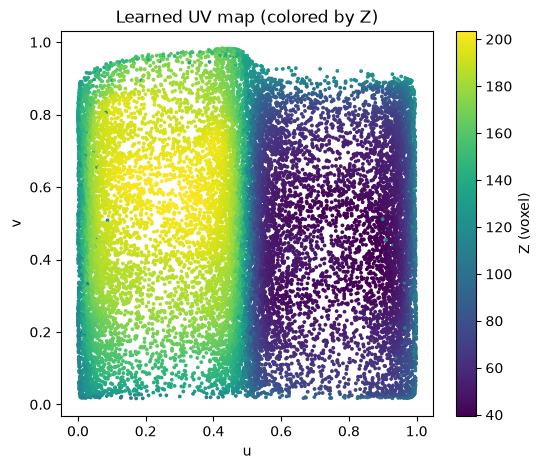

In [19]:
pts = p0.points_voxel.numpy()         # surface points in voxel space
uv_map = p0.get_uv_map()  
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(uv_map[:, 0], uv_map[:, 1], c=pts[:, 0], s=3, cmap='viridis')
ax.set(xlabel='u', ylabel='v', title='Learned UV map (colored by Z)')
fig.colorbar(sc, ax=ax, label='Z (voxel)')
plt.show()

## Project the level-0 intensity volume to UV space

This is the full-resolution step -- reads one timepoint's raw intensity volume at
`INTENSITY_LEVEL` (level 0: ~3.2GB for this dataset, uint16) and samples it along the
learned surface normals to build the UV-space projection.

In [20]:
with timed("t=0 read level-0 intensity volume"):
    vol0 = ds.read_volume(t=T, level=INTENSITY_LEVEL)

print(f"vol0: shape={vol0.shape}, dtype={vol0.dtype}, {vol0.nbytes / 1e9:.2f} GB")

with timed("t=0 project_to_uv_along_normals (level 0)"):
    multilayer0, xyz_vox0, xyz_norm0 = p0.project_to_uv_along_normals(
        vol0, offsets =  np.linspace(5, -20, 30), uv_res=UV_RES, return_maps=True)

max_proj0 = multilayer0.max(axis=0)
print(f"multilayer: {multilayer0.shape}  max_projection: {max_proj0.shape}")

del vol0  # done with the dense level-0 array for this timepoint

# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(max_proj0, cmap="gray")
# ax.set_title("t=0 max projection (level 0)")
# ax.axis("off")
# plt.show()

[t=0 read level-0 intensity volume] 7.17s
vol0: shape=(300, 2291, 2303), dtype=uint16, 3.17 GB
[t=0 project_to_uv_along_normals (level 0)] 3.46s
multilayer: (30, 512, 512)  max_projection: (512, 512)


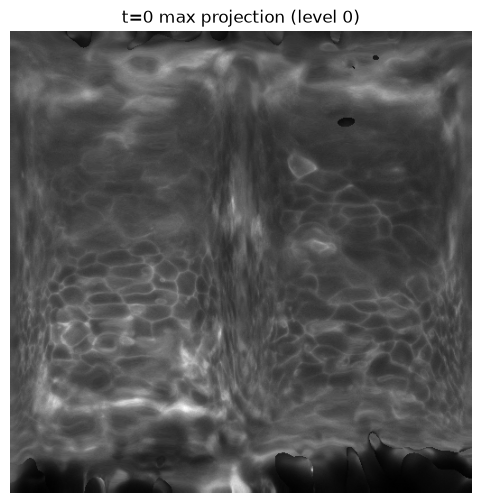

In [21]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(multilayer0[20], cmap="gray")
ax.set_title("t=0 max projection (level 0)")
ax.axis("off")
plt.show()

## t = 1: time-series warm-start

Reuse `t=0`'s trained NuvoMLP as the starting point (`base_model=`) instead of training from
scratch -- the same warm-start trick `01_parameterization_workflow.ipynb` demonstrates on
synthetic data, now timed against the real dataset.

In [33]:
with timed("t=1 segmentation-to-mapping (label_level={})".format(LABEL_LEVEL)):
    p1 = Parameterizer.from_ome_zarr(
        STORE, TOPOLOGY, t=1, level=INTENSITY_LEVEL,
        label_name=LABEL_NAME, label_level=LABEL_LEVEL,
        num_target_points=NUM_TARGET_POINTS,
    )

print(f"t=1 surface points: {p1._full_points.shape[0]}")

with timed("t=1 train (warm-start from t=0)"):
    model1 = p1.train(base_model=p0.get_model())

speedup = timings["t=0 train (cold start)"] / timings["t=1 train (warm-start from t=0)"]
print(f"warm-start speedup vs. t=0 cold start: {speedup:.1f}x")

[t=1 segmentation-to-mapping (label_level=1)] 4.80s
t=1 surface points: 20000
[t=1 train (warm-start from t=0)] 2.58s
warm-start speedup vs. t=0 cold start: 3.0x


[t=1 read level-0 intensity volume] 6.85s
[t=1 project_to_uv_along_normals (level 0)] 1.60s


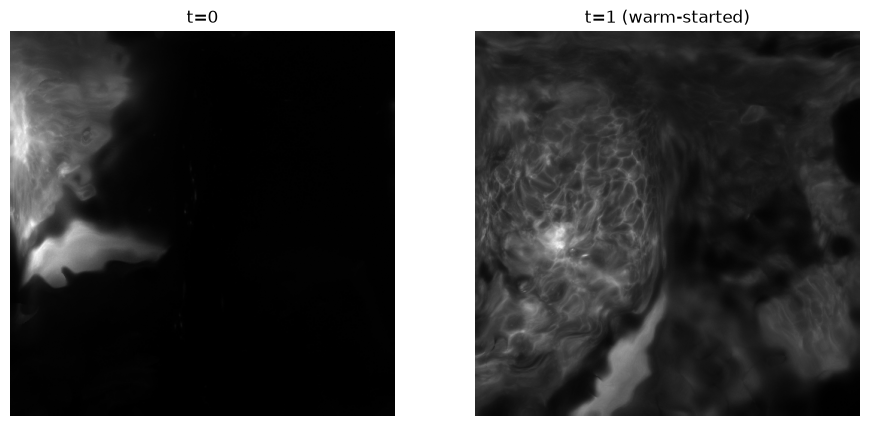

In [34]:
with timed("t=1 read level-0 intensity volume"):
    vol1 = ds.read_volume(1, level=INTENSITY_LEVEL)

with timed("t=1 project_to_uv_along_normals (level 0)"):
    multilayer1, xyz_vox1, xyz_norm1 = p1.project_to_uv_along_normals(
        vol1, uv_res=UV_RES, return_maps=True)

max_proj1 = multilayer1.max(axis=0)
del vol1

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(max_proj0, cmap="gray")
axes[0].set_title("t=0")
axes[1].imshow(max_proj1, cmap="gray")
axes[1].set_title("t=1 (warm-started)")
for a in axes:
    a.axis("off")
plt.show()

## Timing summary

Everything measured above, in one place -- this is the concrete answer to "how long does
level-0 processing actually take" for this dataset on this machine.

In [35]:
width = max(len(k) for k in timings)
for k, v in timings.items():
    print(f"{k:<{width}}  {v:8.2f}s")

open dataset                                     0.00s
t=0 segmentation-to-mapping (label_level=1)      4.77s
t=0 train (cold start)                           7.71s
t=0 read level-0 intensity volume                7.00s
t=0 project_to_uv_along_normals (level 0)        2.52s
t=1 segmentation-to-mapping (label_level=1)      4.80s
t=1 train (warm-start from t=0)                  2.58s
t=1 read level-0 intensity volume                6.85s
t=1 project_to_uv_along_normals (level 0)        1.60s


## Notes

- Segmentation (`marching_cubes`) runs at `LABEL_LEVEL` and is fast; the level-0 intensity
  read and projection are the steps that actually scale with the dataset's real resolution.
- This notebook deliberately does not touch `FlowEstimator`/`3d_native` flow: that path needs
  two adjacent timepoints' *intensity* volumes resident as dense float32 tensors
  simultaneously (~4x the raw per-voxel bytes from dtype widening), which at level 0 for this
  dataset does not fit on a small GPU -- pick a coarser `INTENSITY_LEVEL` for that step, or
  budget accordingly, before running it.
- `SeamlessPipeline.from_ome_zarr` does not yet support `label_level != level` (it raises
  `NotImplementedError` rather than silently mis-projecting) -- this notebook uses
  `Parameterizer.from_ome_zarr` directly, which does support it, for exactly that reason.